In [1]:
# ===================================================================================================
# 🔧 GPU DIAGNOSTIC AND FIX - Run this cell FIRST if you get NVIDIA driver errors
# ===================================================================================================

import torch
import subprocess
import os

print("🔧 GPU DIAGNOSTIC AND TROUBLESHOOTING")
print("=" * 60)

# 1. Check current GPU status
print("1️⃣ GPU Status Check:")
print(f"   PyTorch version: {torch.__version__}")
print(f"   CUDA available: {torch.cuda.is_available()}")
print(f"   CUDA version: {torch.version.cuda if torch.cuda.is_available() else 'Not available'}")

if torch.cuda.is_available():
    print(f"   GPU Device: {torch.cuda.get_device_name()}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("   ✅ GPU is properly detected!")
else:
    print("   ❌ GPU not detected - need to fix this")

# 2. Check runtime type
try:
    import google.colab
    print("\n2️⃣ Runtime Check:")
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if result.returncode == 0:
        print("   ✅ nvidia-smi working - GPU runtime active")
        # Extract GPU info from nvidia-smi
        lines = result.stdout.split('\n')
        for line in lines:
            if 'Tesla' in line or 'T4' in line or 'V100' in line or 'A100' in line or 'K80' in line:
                print(f"   🚀 Detected: {line.strip()}")
    else:
        print("   ❌ nvidia-smi failed - CPU runtime detected")
        print("   💡 SOLUTION: Go to Runtime → Change runtime type → Hardware accelerator: GPU")
        print("   💡 Then: Runtime → Restart and run all")
except ImportError:
    print("\n2️⃣ Not running in Google Colab")

# 3. Force CUDA environment variables (sometimes helps)
print("\n3️⃣ Setting CUDA Environment:")
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
print("   ✅ CUDA environment variables set")

# 4. Test CUDA operations
print("\n4️⃣ CUDA Operations Test:")
try:
    if torch.cuda.is_available():
        # Test basic CUDA operations
        device = torch.device('cuda:0')
        test_tensor = torch.randn(10, 10).to(device)
        test_result = torch.matmul(test_tensor, test_tensor.T)
        print(f"   ✅ CUDA tensor operations successful on {device}")
        print(f"   💾 Current GPU memory: {torch.cuda.memory_allocated() / 1e6:.1f} MB")

        # Clear memory
        del test_tensor, test_result
        torch.cuda.empty_cache()
        print("   🧹 GPU memory cleared")
    else:
        print("   ❌ Cannot test CUDA operations - GPU not available")
        print("\n🚨 ACTION REQUIRED:")
        print("   1. Go to 'Runtime' menu → 'Change runtime type'")
        print("   2. Set 'Hardware accelerator' to 'GPU' (T4 or V100)")
        print("   3. Click 'Save'")
        print("   4. Go to 'Runtime' menu → 'Restart and run all'")
        print("   5. Wait for restart and re-run this cell")
except Exception as e:
    print(f"   ❌ CUDA test failed: {e}")

# 5. GPU Requirements Summary
print("\n" + "=" * 60)
print("📋 REQUIREMENTS FOR CoFT TRAINING:")
print("   • Google Colab with GPU runtime (T4/V100)")
print("   • CUDA-compatible PyTorch installation")
print("   • ~2-4 GB GPU memory per experiment")
print("   • Estimated time: 30min (diagnostic), 2h (quick), 8h (optimize)")
print("=" * 60)

print("\n✅ GPU diagnostic completed!")
if torch.cuda.is_available():
    print("🚀 Ready for CoFT training!")
else:
    print("⚠️  Enable GPU runtime before proceeding with grid search")


🔧 GPU DIAGNOSTIC AND TROUBLESHOOTING
1️⃣ GPU Status Check:
   PyTorch version: 2.6.0+cu124
   CUDA available: True
   CUDA version: 12.4
   GPU Device: NVIDIA L4
   GPU Memory: 23.8 GB
   ✅ GPU is properly detected!

2️⃣ Runtime Check:
   ✅ nvidia-smi working - GPU runtime active

3️⃣ Setting CUDA Environment:
   ✅ CUDA environment variables set

4️⃣ CUDA Operations Test:
   ✅ CUDA tensor operations successful on cuda:0
   💾 Current GPU memory: 8.5 MB
   🧹 GPU memory cleared

📋 REQUIREMENTS FOR CoFT TRAINING:
   • Google Colab with GPU runtime (T4/V100)
   • CUDA-compatible PyTorch installation
   • ~2-4 GB GPU memory per experiment
   • Estimated time: 30min (diagnostic), 2h (quick), 8h (optimize)

✅ GPU diagnostic completed!
🚀 Ready for CoFT training!


In [2]:
# ===================================================================
# CELL 1: Setup & Dependencies
# ===================================================================

import os
import sys
import time
import json
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("🚀 CoFT Parameter Grid Search v3.0.0")
print("✅ Dependencies loaded successfully")

# Configuration Options
DATASET_OPTIONS = ['HAR', 'sleep', 'Epilepsy', 'pFD']
MODE_OPTIONS = ['diagnostic', 'quick', 'optimize', 'mega_optimize']

# Default settings
SELECTED_DATASET = 'HAR'  # Change this as needed
SELECTED_MODE = 'diagnostic'  # Start with diagnostic
MAX_TIMEOUT = 1800  # 30 minutes per experiment (increased for model preparation)

# Exhaustive search settings
ENABLE_EXHAUSTIVE = True  # Set False to use reduced grid for testing
PARALLEL_EXPERIMENTS = False  # Future: run multiple experiments in parallel

print(f"📊 Default Dataset: {SELECTED_DATASET}")
print(f"🔍 Default Mode: {SELECTED_MODE}")
print(f"⏱️ Timeout per experiment: {MAX_TIMEOUT}s")


🚀 CoFT Parameter Grid Search v3.0.0
✅ Dependencies loaded successfully
📊 Default Dataset: HAR
🔍 Default Mode: diagnostic
⏱️ Timeout per experiment: 1800s


In [3]:
# ===================================================================
# CELL 2: Project Setup & Configuration
# ===================================================================

print("🔧 Setting up CoFT project...")

def mount_drive_if_needed():
    """Mount Google Drive if not already mounted"""
    if not os.path.exists('/content/drive'):
        try:
            from google.colab import drive
            print("📁 Mounting Google Drive...")
            drive.mount('/content/drive')
            print("✅ Google Drive mounted successfully!")
            return True
        except ImportError:
            print("⚠️  Not running in Google Colab - skipping drive mount")
            return False
    else:
        print("✅ Google Drive already mounted")
        return True

def find_coft_project():
    """Find CoFT project in common locations"""

    # Search paths in order of preference
    search_paths = [
        '/content/drive/MyDrive/CoFT',
        '/content/drive/My Drive/CoFT',
        '/content/CoFT',
        '/content/coft',
        '/content/CoFT-main',
        '/content'
    ]

    print("🔍 Searching for CoFT project...")

    for path in search_paths:
        if os.path.exists(path):
            # Check if this looks like a CoFT project
            key_files = ['main.py', 'models', 'trainer']
            found_files = [f for f in key_files if os.path.exists(os.path.join(path, f))]

            if len(found_files) >= 2:  # At least 2 key components found
                print(f"✅ Found CoFT project at: {path}")
                return path
            else:
                print(f"📁 Found directory but incomplete: {path}")

    print("❌ CoFT project not found in common locations")
    return None

# Auto-mount drive if in Colab
mount_drive_if_needed()

# Find and navigate to CoFT project
project_path = find_coft_project()

if project_path:
    os.chdir(project_path)
    print(f"📂 Changed to: {os.getcwd()}")

    # Show project structure
    print("\n📁 Project structure:")
    items = []
    for item in sorted(os.listdir('.')):
        if os.path.isdir(item):
            items.append(f"   📁 {item}/")
        else:
            items.append(f"   📄 {item}")

    # Show only first 15 items to avoid clutter
    for item in items[:15]:
        print(item)
    if len(items) > 15:
        print(f"   ... and {len(items)-15} more items")

else:
    print("❌ CoFT project not found!")
    print("\n📋 Please setup your CoFT project:")
    print("1. Mount Google Drive and upload to /content/drive/MyDrive/CoFT")
    print("2. Or upload CoFT.zip and extract to /content/CoFT")
    print("3. Or clone from GitHub: !git clone <your-repo-url>")
    print("\n💡 Then re-run this cell")

# Verify project structure
required_files = [
    'main.py',
    'models/coft_loss.py',
    'trainer/trainer_coft.py',
    'config_files',
    'dataloader'
]

missing_files = []
for file in required_files:
    if not os.path.exists(file):
        missing_files.append(file)

if missing_files:
    print(f"❌ Missing files: {missing_files}")
    print("🔧 Please ensure all CoFT project files are available")
else:
    print("✅ All required project files found")

print(f"📂 Current working directory: {os.getcwd()}")

# Install additional dependencies if needed
try:
    import torch
    print(f"✅ PyTorch {torch.__version__} available")
except ImportError:
    print("📦 Installing PyTorch...")
    !pip install torch torchvision torchaudio

# Create results directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = f"gridsearch_{timestamp}"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"📁 Results directory: {RESULTS_DIR}")


🔧 Setting up CoFT project...
📁 Mounting Google Drive...
Mounted at /content/drive
✅ Google Drive mounted successfully!
🔍 Searching for CoFT project...
✅ Found CoFT project at: /content/drive/MyDrive/CoFT
📂 Changed to: /content/drive/.shortcut-targets-by-id/1mzBQDoLNOm7LuL4w42HoBhLimEjZY1GF/CoFT

📁 Project structure:
   📁 .cursor/
   📄 .cursorignore
   📄 .gitattributes
   📄 .gitignore
   📄 CHANGELOG.md
   📄 CoFT.png
   📄 CoFT_Architecture.png
   📄 README.md
   📁 __pycache__/
   📄 amp_output.log
   📄 baseline_output.log
   📄 compare_performance.sh
   📁 config_files/
   📁 data/
   📁 data_preprocessing/
   ... and 18 more items
✅ All required project files found
📂 Current working directory: /content/drive/.shortcut-targets-by-id/1mzBQDoLNOm7LuL4w42HoBhLimEjZY1GF/CoFT
✅ PyTorch 2.6.0+cu124 available
📁 Results directory: gridsearch_20250622_095257


In [4]:
# ===================================================================
# CELL 2.1: Manual Project Navigation (if auto-detection failed)
# ===================================================================

# Run this cell ONLY if Cell 2 didn't find your CoFT project automatically

def manual_setup():
    """Manual setup for CoFT project location"""

    print("🔧 Manual CoFT project setup...")

    # Option 1: Navigate to specific Google Drive path
    gdrive_path = '/content/drive/MyDrive/CoFT'
    if os.path.exists(gdrive_path):
        os.chdir(gdrive_path)
        print(f"✅ Navigated to: {gdrive_path}")
        return True

    # Option 2: List available directories to help user find project
    print("📁 Available directories in /content/:")
    if os.path.exists('/content'):
        for item in os.listdir('/content'):
            if os.path.isdir(f'/content/{item}'):
                print(f"   📁 /content/{item}")

    if os.path.exists('/content/drive/MyDrive'):
        print("\n📁 Available in Google Drive:")
        for item in os.listdir('/content/drive/MyDrive'):
            if os.path.isdir(f'/content/drive/MyDrive/{item}'):
                print(f"   📁 /content/drive/MyDrive/{item}")

    print("\n💡 To manually navigate:")
    print("   import os")
    print("   os.chdir('/path/to/your/CoFT/project')")
    print("   print(f'Current directory: {os.getcwd()}')")

    return False

# Uncomment the line below if you need manual setup
# manual_setup()


In [5]:
# ===================================================================
# CELL 2.5: Prepare for Real Training
# ===================================================================

# Quick project status check
print(f"📍 Working from: {os.getcwd()}")
if os.path.exists('main.py'):
    size = os.path.getsize('main.py')
    print(f"✅ main.py found ({size} bytes)")
else:
    print("❌ main.py not found - please navigate to CoFT project folder first")
    print("💡 Use Cell 2.1 for manual navigation if needed")
print("─" * 60)

def prepare_base_models():
    """Prepare base models for real training by running self_supervised training"""

    print("🔧 Preparing base models for real training...")

    # Check if we're using real main.py
    if not os.path.exists('main.py') or os.path.getsize('main.py') < 10000:
        print("❌ Real main.py not found. Please upload the complete CoFT project.")
        print("   Required: Full CoFT repository with all model files")
        return False

    # Check for self-supervised model
    model_path = f"experiments_logs/{SELECTED_DATASET}_self_supervised.pkl"

    if os.path.exists(model_path):
        print(f"✅ Base model already exists: {model_path}")
        return True

    print(f"📝 Base model not found. Running self_supervised training...")
    print(f"⏳ This will take ~10-15 minutes for real training...")

    try:
        import subprocess
        result = subprocess.run([
            'python', 'main.py',
            '--training_mode', 'self_supervised',
            '--selected_dataset', SELECTED_DATASET
        ], capture_output=True, text=True, timeout=1800)  # 30 min timeout

        if result.returncode == 0:
            print("✅ Self-supervised training completed!")
            print(f"📊 Model saved to: {model_path}")
            return True
        else:
            print(f"❌ Self-supervised training failed: {result.stderr[:500]}")
            return False

    except subprocess.TimeoutExpired:
        print("⏰ Self-supervised training timeout (>30 min)")
        return False
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return False

def verify_real_project():
    """Verify that real CoFT project files are available"""

    print("🔍 Verifying real CoFT project structure...")

    required_files = [
        ('main.py', 10000),  # Should be >10KB for real file
        ('models/model.py', 1000),
        ('models/TC.py', 1000),
        ('models/frequency_model.py', 1000),
        ('models/coft_loss.py', 1000),
        ('trainer/trainer_coft.py', 1000),
        ('trainer/trainer_baseline.py', 1000)
    ]

    missing = []
    for file_path, min_size in required_files:
        if not os.path.exists(file_path):
            missing.append(f"{file_path} (not found)")
        elif os.path.getsize(file_path) < min_size:
            missing.append(f"{file_path} (too small: {os.path.getsize(file_path)} bytes)")

    if missing:
        print("❌ Missing or incomplete files:")
        for item in missing:
            print(f"   • {item}")
        print("\n📋 Please ensure you have uploaded the complete CoFT project!")
        print("   Options:")
        print("   1. Upload CoFT.zip and extract it")
        print("   2. Clone from GitHub repository")
        print("   3. Mount Google Drive with CoFT folder")
        return False

    print("✅ All required files found!")

    # Check for datasets
    dataset_paths = {
        'HAR': 'data/HAR',
        'sleep': 'data/sleepEDF',
        'Epilepsy': 'data/Epilepsy',
        'pFD': 'data/FD-B'
    }

    if SELECTED_DATASET in dataset_paths:
        data_path = dataset_paths[SELECTED_DATASET]
        if not os.path.exists(data_path):
            print(f"\n⚠️  Dataset not found: {data_path}")
            print(f"   Please download {SELECTED_DATASET} dataset to: {data_path}/")
            print("   Or change SELECTED_DATASET in Cell 1")

    return True

# Run verification
print("🚀 Preparing for REAL TRAINING with actual datasets...")
print(f"📂 Current working directory: {os.getcwd()}")
is_real_project = verify_real_project()

if is_real_project:
    print("\n✅ Real CoFT project detected!")
    print("🎯 Ready for real parameter optimization")

    # Create required directories
    os.makedirs('experiments_logs', exist_ok=True)
    os.makedirs('data', exist_ok=True)

    # Prepare base models if needed
    if SELECTED_MODE != 'diagnostic':  # Skip for quick testing
        prepare_base_models()

    print("\n📋 Next steps:")
    print("1. ✅ Real project verified")
    print("2. 🔄 Run Cell 4 (Grid Search Engine)")
    print("3. 🧪 Execute parameter search with real training")
else:
    print("\n❌ Real project not found")
    print("📋 Please upload the complete CoFT project before proceeding")
    print("\n📝 Instructions for uploading CoFT project:")
    print("1. Upload all project files to Colab")
    print("2. Or mount Google Drive with CoFT folder")
    print("3. Ensure datasets are in 'data/' folder")
    print("4. Re-run this cell after setup")


📍 Working from: /content/drive/.shortcut-targets-by-id/1mzBQDoLNOm7LuL4w42HoBhLimEjZY1GF/CoFT
✅ main.py found (16004 bytes)
────────────────────────────────────────────────────────────
🚀 Preparing for REAL TRAINING with actual datasets...
📂 Current working directory: /content/drive/.shortcut-targets-by-id/1mzBQDoLNOm7LuL4w42HoBhLimEjZY1GF/CoFT
🔍 Verifying real CoFT project structure...
✅ All required files found!

✅ Real CoFT project detected!
🎯 Ready for real parameter optimization

📋 Next steps:
1. ✅ Real project verified
2. 🔄 Run Cell 4 (Grid Search Engine)
3. 🧪 Execute parameter search with real training


In [6]:
# ===================================================================
# CELL 4: Grid Search Engine Class - FULLY FIXED VERSION
# ===================================================================

class CoFTGridSearch:
    def __init__(self, dataset='HAR', results_dir=None):
        self.dataset = dataset
        self.results_dir = results_dir or f"gridsearch_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        self.results_file = f"{self.results_dir}/results.csv"
        self.best_result = {'accuracy': 0, 'params': {}}

        # Create results directory
        os.makedirs(self.results_dir, exist_ok=True)

        # Initialize results CSV
        self.init_results_file()

        print(f"🔥 CoFT Grid Search initialized - REAL TRAINING MODE (FULLY FIXED)")
        print(f"📊 Dataset: {self.dataset}")
        print(f"📁 Results: {self.results_dir}")

        # Check GPU availability at initialization
        gpu_status = self.check_gpu_availability()
        if gpu_status['available']:
            print(f"✅ GPU Ready: {gpu_status['message']}")
        else:
            print(f"⚠️  GPU Issue: {gpu_status['message']}")
            print("💡 Run Cell 1 (GPU Diagnostic) to fix GPU issues")

    def check_gpu_availability(self):
        """Check if GPU is properly available for training"""
        import torch
        import subprocess

        # Check PyTorch CUDA
        if not torch.cuda.is_available():
            return {
                'available': False,
                'message': 'PyTorch CUDA not available'
            }

        # Check nvidia-smi
        try:
            result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=10)
            if result.returncode != 0:
                return {
                    'available': False,
                    'message': 'nvidia-smi command failed'
                }
        except:
            return {
                'available': False,
                'message': 'nvidia-smi not accessible'
            }

        # Test basic CUDA operations
        try:
            device = torch.device('cuda:0')
            test_tensor = torch.randn(10, 10).to(device)
            _ = torch.matmul(test_tensor, test_tensor.T)
            del test_tensor
            torch.cuda.empty_cache()

            return {
                'available': True,
                'message': f'{torch.cuda.get_device_name()} ready'
            }
        except Exception as e:
            return {
                'available': False,
                'message': f'CUDA operations failed: {str(e)[:50]}'
            }

    def init_results_file(self):
        """Initialize CSV file with headers"""
        headers = [
            'exp_id', 'lambda_cotraining', 'lambda_consistency',
            'ensemble', 'test_accuracy', 'duration', 'verification', 'timestamp'
        ]

        with open(self.results_file, 'w') as f:
            f.write(','.join(headers) + '\n')

    def backup_files(self):
        """Create backup of original files"""
        if os.path.exists('models/coft_loss.py'):
            shutil.copy('models/coft_loss.py', 'models/coft_loss.py.backup')
        if os.path.exists('trainer/trainer_coft.py'):
            shutil.copy('trainer/trainer_coft.py', 'trainer/trainer_coft.py.backup')

    def restore_files(self):
        """Restore original files from backup"""
        if os.path.exists('models/coft_loss.py.backup'):
            shutil.copy('models/coft_loss.py.backup', 'models/coft_loss.py')
        if os.path.exists('trainer/trainer_coft.py.backup'):
            shutil.copy('trainer/trainer_coft.py.backup', 'trainer/trainer_coft.py')

    def update_coft_loss_params(self, lambda_ct, lambda_cs):
        """Update CoFT loss parameters - FIXED VERSION"""
        if not os.path.exists('models/coft_loss.py'):
            print("⚠️  Warning: coft_loss.py not found")
            return False

        # Read file
        with open('models/coft_loss.py', 'r') as f:
            content = f.read()

        # 🔥 CRITICAL FIX: Improved regex patterns for decimal numbers
        import re
        
        # Fix lambda_cotraining with proper decimal pattern  
        content = re.sub(
            r'self\.lambda_cotraining\s*=\s*[0-9]*\.?[0-9]+',
            f'self.lambda_cotraining = {lambda_ct}',
            content
        )
        
        # Fix lambda_consistency with proper decimal pattern
        content = re.sub(
            r'self\.lambda_consistency\s*=\s*[0-9]*\.?[0-9]+', 
            f'self.lambda_consistency = {lambda_cs}',
            content
        )

        # Write back with verification
        with open('models/coft_loss.py', 'w') as f:
            f.write(content)
            
        # Immediate verification
        with open('models/coft_loss.py', 'r') as f:
            verify_content = f.read()
            if f"lambda_cotraining = {lambda_ct}" not in verify_content:
                print(f"❌ CRITICAL: lambda_cotraining update failed!")
                return False
            if f"lambda_consistency = {lambda_cs}" not in verify_content:
                print(f"❌ CRITICAL: lambda_consistency update failed!")
                return False

        return True

    def update_ensemble_method(self, method):
        """Update ensemble method in trainer - FIXED VERSION"""
        if not os.path.exists('trainer/trainer_coft.py'):
            print("⚠️  Warning: trainer_coft.py not found")
            return False

        # Read file
        with open('trainer/trainer_coft.py', 'r') as f:
            content = f.read()

        # 🔥 CRITICAL FIX: More reliable ensemble switching patterns
        import re
        if method == "temporal_only":
            # Switch to temporal only mode - multiple patterns for robustness
            content = re.sub(
                r'final_predictions\s*=\s*\(predictions\s*\+\s*freq_predictions\)\s*/\s*2.*',
                'final_predictions = predictions  # TEMPORAL_ONLY_MODE',
                content
            )
            content = re.sub(
                r'final_predictions\s*=\s*ensemble_predictions.*',
                'final_predictions = predictions  # TEMPORAL_ONLY_MODE', 
                content
            )
            
        elif method == "simple_average":
            # Switch to simple average mode
            content = re.sub(
                r'final_predictions\s*=\s*predictions\s*#\s*TEMPORAL_ONLY_MODE.*',
                'final_predictions = (predictions + freq_predictions) / 2  # SIMPLE_AVERAGE',
                content
            )

        # Write back with verification
        with open('trainer/trainer_coft.py', 'w') as f:
            f.write(content)

        # Immediate verification  
        with open('trainer/trainer_coft.py', 'r') as f:
            verify_content = f.read()
            if method == "temporal_only" and "TEMPORAL_ONLY_MODE" not in verify_content:
                print(f"❌ CRITICAL: temporal_only ensemble update failed!")
                return False
            elif method == "simple_average" and "SIMPLE_AVERAGE" not in verify_content and "(predictions + freq_predictions) / 2" not in verify_content:
                print(f"❌ CRITICAL: simple_average ensemble update failed!")
                return False

        return True

    def verify_parameters(self, lambda_ct, lambda_cs, ensemble):
        """Verify parameter changes were applied - ENHANCED VERSION"""
        verification_score = 0
        errors = []

        # Check lambda_cotraining
        if os.path.exists('models/coft_loss.py'):
            with open('models/coft_loss.py', 'r') as f:
                content = f.read()
                if f"lambda_cotraining = {lambda_ct}" in content:
                    verification_score += 1
                else:
                    errors.append(f"lambda_cotraining = {lambda_ct} not found")

        # Check lambda_consistency
        if os.path.exists('models/coft_loss.py'):
            with open('models/coft_loss.py', 'r') as f:
                content = f.read()
                if f"lambda_consistency = {lambda_cs}" in content:
                    verification_score += 1
                else:
                    errors.append(f"lambda_consistency = {lambda_cs} not found")

        # Check ensemble method
        if os.path.exists('trainer/trainer_coft.py'):
            with open('trainer/trainer_coft.py', 'r') as f:
                content = f.read()
                if ensemble == "temporal_only" and "TEMPORAL_ONLY_MODE" in content:
                    verification_score += 1
                elif ensemble == "simple_average" and ("SIMPLE_AVERAGE" in content or "(predictions + freq_predictions) / 2" in content):
                    verification_score += 1
                else:
                    errors.append(f"ensemble method {ensemble} not applied")

        # Log any verification errors
        if errors:
            print(f"   ⚠️  Verification errors: {'; '.join(errors)}")

        return f"{verification_score}/3"

    def parse_test_accuracy(self, stdout, stderr):
        """Parse test accuracy from training output"""
        import re

        print("   🔍 Parsing accuracy from output...")

        # Common patterns for real test accuracy from CoFT training
        patterns = [
            r'Test\s+Accuracy.*?([0-9]+\.?[0-9]*)%',           # Test Accuracy: 75.64%
            r'test_acc.*?([0-9]+\.?[0-9]*)',                   # test_acc: 0.7564
            r'Test.*?acc.*?([0-9]+\.?[0-9]*)',                 # Test acc: 75.64
            r'Final.*?accuracy.*?([0-9]+\.?[0-9]*)',           # Final accuracy: 75.64
            r'accuracy.*?([0-9]+\.?[0-9]*)%',                  # accuracy: 75.64%
            r'ACC.*?([0-9]+\.?[0-9]*)',                        # ACC: 75.64
            r'Test.*?([0-9]+\.?[0-9]*)%',                      # Test: 75.64%
            r'Best.*?Acc.*?([0-9]+\.?[0-9]*)',                 # Best Acc: 75.64
            r'ft_1p.*?Test.*?([0-9]+\.?[0-9]*)',               # ft_1p mode Test: 75.64
        ]

        # Search in stdout first, then stderr
        for text in [stdout, stderr]:
            for pattern in patterns:
                matches = re.findall(pattern, text, re.IGNORECASE)
                if matches:
                    try:
                        acc = float(matches[-1])  # Take the last match
                        # Convert to percentage if needed
                        if acc <= 1.0:
                            acc *= 100
                        print(f"   ✓ Found accuracy: {acc}% (pattern: {pattern[:20]}...)")
                        return round(acc, 4)
                    except:
                        continue

        # Try to find any percentage value as fallback
        percentage_pattern = r'([0-9]+\.?[0-9]*)%'
        for text in [stdout, stderr]:
            matches = re.findall(percentage_pattern, text)
            if matches:
                try:
                    # Take the highest percentage value (likely accuracy)
                    acc_values = [float(m) for m in matches if 50 <= float(m) <= 100]
                    if acc_values:
                        acc = max(acc_values)
                        print(f"   ✓ Found percentage: {acc}% (fallback)")
                        return round(acc, 4)
                except:
                    continue

        print("   ❌ Could not parse accuracy from output")
        return None

    def run_single_experiment(self, exp_id, lambda_ct, lambda_cs, ensemble, description):
        """Run a single optimization experiment with REAL TRAINING - FULLY FIXED"""
        import time  # 🔥 CRITICAL FIX: Import time at the top to avoid UnboundLocalError
        start_time = time.time()

        print(f"🔬 Experiment {exp_id}: {description}")
        print(f"   Parameters: λ_ct={lambda_ct}, λ_cs={lambda_cs}, ensemble={ensemble}")

        # 🚨 PRE-CHECK: Verify GPU before training
        gpu_status = self.check_gpu_availability()
        if not gpu_status['available']:
            print(f"   ❌ GPU not available: {gpu_status['message']}")
            print(f"   💡 SOLUTION: Run Cell 1 (GPU Diagnostic) to fix this!")
            return "GPU_NOT_AVAILABLE", 0, "0/3"

        # Backup files
        self.backup_files()

        try:
            # 🔥 CRITICAL FIX: Update parameters with enhanced verification
            lambda_success = self.update_coft_loss_params(lambda_ct, lambda_cs)
            ensemble_success = self.update_ensemble_method(ensemble)
            
            if not lambda_success or not ensemble_success:
                print(f"   ❌ Parameter update failed!")
                return "PARAM_UPDATE_FAILED", 0, "0/3"

            # Verify changes
            verification = self.verify_parameters(lambda_ct, lambda_cs, ensemble)
            print(f"   ✓ Parameter verification: {verification}")

            # 🔥 CRITICAL: Force file system sync before training
            time.sleep(2)  # Give filesystem time to sync
            
            # Double-check parameters are actually applied
            if verification != "3/3":
                print(f"   ❌ Parameter verification failed: {verification}")
                print(f"   💡 Parameters might not be properly applied")

            # Create experiment log
            exp_log = f"{self.results_dir}/experiment_{exp_id}.log"
            with open(exp_log, 'w') as f:
                f.write(f"Experiment {exp_id}: {description}\n")
                f.write(f"lambda_cotraining: {lambda_ct}\n")
                f.write(f"lambda_consistency: {lambda_cs}\n")
                f.write(f"ensemble_method: {ensemble}\n")
                f.write(f"verification: {verification}\n")
                f.write("---\n")

            print(f"   ⏳ Running REAL training (timeout: {MAX_TIMEOUT}s)...")

            import subprocess

            # 🔥 CRITICAL FIX: Use consistent experiment structure
            result = subprocess.run([
                'python', 'main.py',
                '--training_mode', 'ft_1p',
                '--selected_dataset', self.dataset,
                '--experiment_description', 'HAR_experiments',
                '--run_description', f'gridsearch_exp_{exp_id}',
                '--enable_coft'  # ✅ FIXED: No value needed for store_true action
            ], capture_output=True, text=True, timeout=MAX_TIMEOUT)

            # Save complete output to log
            with open(exp_log, 'a') as f:
                f.write("COMMAND EXECUTED:\n")
                f.write(f"python main.py --training_mode ft_1p --selected_dataset {self.dataset} --enable_coft\n\n")
                f.write("STDOUT:\n")
                f.write(result.stdout)
                f.write("\nSTDERR:\n")
                f.write(result.stderr)
                f.write(f"\nReturn code: {result.returncode}\n")

            # Check if training succeeded
            if result.returncode != 0:
                print(f"   ❌ Training failed with return code: {result.returncode}")
                print(f"   📝 Check log file: {exp_log}")

                # Check for specific GPU/CUDA errors
                error_output = result.stdout + result.stderr
                if "Found no NVIDIA driver" in error_output:
                    print(f"   🔧 NVIDIA DRIVER ERROR detected!")
                    print(f"   💡 SOLUTION: Run Cell 1 (GPU Diagnostic) to fix GPU setup")
                    test_acc = "GPU_DRIVER_ERROR"
                elif "CUDA" in error_output and ("error" in error_output.lower() or "failed" in error_output.lower()):
                    print(f"   🔧 CUDA ERROR detected!")
                    print(f"   💡 SOLUTION: Check GPU runtime and restart if needed")
                    test_acc = "CUDA_ERROR"
                else:
                    # Show error snippet for debugging
                    if result.stderr:
                        error_preview = result.stderr[:300]
                        print(f"   🔍 Error preview: {error_preview}...")
                    test_acc = "TRAINING_FAILED"
            else:
                # Parse test accuracy from output
                test_acc = self.parse_test_accuracy(result.stdout, result.stderr)

                if test_acc is None:
                    print(f"   ❌ Could not parse test accuracy from output")
                    print(f"   📝 Check log file: {exp_log}")
                    test_acc = "PARSE_ERROR"
                else:
                    print(f"   ✅ Result: Test Accuracy = {test_acc}%")

            duration = time.time() - start_time
            timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

            # Save result
            result_row = f"{exp_id},{lambda_ct},{lambda_cs},{ensemble},{test_acc},{duration:.1f},{verification},{timestamp}\n"
            with open(self.results_file, 'a') as f:
                f.write(result_row)

            # Update best result (only if valid accuracy)
            if isinstance(test_acc, (int, float)) and test_acc > self.best_result['accuracy']:
                self.best_result = {
                    'accuracy': test_acc,
                    'params': {
                        'lambda_ct': lambda_ct,
                        'lambda_cs': lambda_cs,
                        'ensemble': ensemble,
                        'exp_id': exp_id
                    }
                }
                print(f"   🏆 NEW BEST: {test_acc}%")

                # Save best result
                with open(f"{self.results_dir}/best_result.txt", 'w') as f:
                    f.write(f"Best parameters: λ_ct={lambda_ct}, λ_cs={lambda_cs}, ensemble={ensemble}\n")
                    f.write(f"Test accuracy: {test_acc}%\n")
                    f.write(f"Experiment ID: {exp_id}\n")

            return test_acc, duration, verification

        except subprocess.TimeoutExpired:
            print(f"   ⏰ TIMEOUT: Experiment exceeded {MAX_TIMEOUT}s")
            duration = time.time() - start_time
            timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

            result_row = f"{exp_id},{lambda_ct},{lambda_cs},{ensemble},TIMEOUT,{duration:.1f},0/3,{timestamp}\n"
            with open(self.results_file, 'a') as f:
                f.write(result_row)

            return "TIMEOUT", duration, "0/3"

        except Exception as e:
            print(f"   ❌ Failed: {str(e)}")
            duration = time.time() - start_time
            timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

            result_row = f"{exp_id},{lambda_ct},{lambda_cs},{ensemble},FAILED,{duration:.1f},0/3,{timestamp}\n"
            with open(self.results_file, 'a') as f:
                f.write(result_row)

            return "FAILED", duration, "0/3"

        finally:
            # Always restore files
            self.restore_files()
            print("─" * 70)

print("🔥 CoFT Grid Search Engine initialized - READY FOR COLAB!")


🔥 CoFT Grid Search Engine initialized - READY FOR COLAB!


In [ ]:
# ===================================================================
# 🔧 CRITICAL FIX: Parameter Debug & Validation Cell
# ===================================================================

def debug_parameter_application():
    """Debug and validate that parameter changes actually work"""
    
    print("🔧 DEBUGGING PARAMETER APPLICATION")
    print("=" * 60)
    
    # 1. Check current parameter values
    print("1️⃣ Current parameter values:")
    if os.path.exists('models/coft_loss.py'):
        with open('models/coft_loss.py', 'r') as f:
            content = f.read()
            # Extract current lambda values
            import re
            ct_match = re.search(r'lambda_cotraining\s*=\s*([0-9\.]+)', content)
            cs_match = re.search(r'lambda_consistency\s*=\s*([0-9\.]+)', content)
            
            if ct_match and cs_match:
                print(f"   λ_cotraining: {ct_match.group(1)}")
                print(f"   λ_consistency: {cs_match.group(1)}")
            else:
                print("   ❌ Could not extract lambda values")
    
    # 2. Check ensemble method
    print("\n2️⃣ Current ensemble method:")
    if os.path.exists('trainer/trainer_coft.py'):
        with open('trainer/trainer_coft.py', 'r') as f:
            content = f.read()
            if "TEMPORAL_ONLY_MODE" in content:
                print("   📊 Currently: temporal_only")
            elif "SIMPLE_AVERAGE" in content or "(predictions + freq_predictions) / 2" in content:
                print("   📊 Currently: simple_average") 
            else:
                print("   ❓ Unknown ensemble mode")
    
    # 3. Test parameter update
    print("\n3️⃣ Testing parameter update mechanism:")
    
    # Create a temporary test
    test_grid = CoFTGridSearch(dataset=SELECTED_DATASET, results_dir=f"debug_test_{int(time.time())}")
    
    # Test lambda update
    print("   🧪 Testing lambda update...")
    lambda_success = test_grid.update_coft_loss_params(0.999, 0.888)
    if lambda_success:
        print("   ✅ Lambda update successful")
    else:
        print("   ❌ Lambda update failed")
    
    # Test ensemble update  
    print("   🧪 Testing ensemble update...")
    ensemble_success = test_grid.update_ensemble_method("temporal_only")
    if ensemble_success:
        print("   ✅ Ensemble update successful")
    else:
        print("   ❌ Ensemble update failed")
    
    # Verify test changes
    verification = test_grid.verify_parameters(0.999, 0.888, "temporal_only")
    print(f"   📊 Test verification: {verification}")
    
    # Restore original files
    test_grid.restore_files()
    print("   🔄 Restored original files")
    
    # 4. Check for low accuracy cause
    print("\n4️⃣ Investigating low accuracy (16.76%):")
    
    # Check if base models exist
    model_path = f"experiments_logs/{SELECTED_DATASET}_self_supervised.pkl"
    if os.path.exists(model_path):
        print(f"   ✅ Base model exists: {model_path}")
        print(f"   📏 Size: {os.path.getsize(model_path)} bytes")
    else:
        print(f"   ❌ Base model missing: {model_path}")
        print("   💡 This could explain low accuracy!")
        
    # Check for dataset
    dataset_paths = {
        'HAR': 'data/HAR',
        'sleep': 'data/sleepEDF', 
        'Epilepsy': 'data/Epilepsy',
        'pFD': 'data/FD-B'
    }
    
    if SELECTED_DATASET in dataset_paths:
        data_path = dataset_paths[SELECTED_DATASET]
        if os.path.exists(data_path):
            print(f"   ✅ Dataset found: {data_path}")
            # Count files
            files = [f for f in os.listdir(data_path) if f.endswith(('.pkl', '.npz', '.npy', '.csv'))]
            print(f"   📊 Data files: {len(files)}")
        else:
            print(f"   ❌ Dataset missing: {data_path}")
            print("   💡 This could explain low accuracy!")
    
    print("\n" + "=" * 60)
    print("🔍 DIAGNOSIS COMPLETE")
    
    # Recommendations
    print("\n💡 RECOMMENDATIONS:")
    if not os.path.exists(model_path):
        print("   1. Run self_supervised training first:")
        print("      !python main.py --training_mode self_supervised --selected_dataset HAR")
    
    if SELECTED_DATASET in dataset_paths and not os.path.exists(dataset_paths[SELECTED_DATASET]):
        print("   2. Download and place dataset in correct folder")
        
    print("   3. After fixing issues, re-run grid search")
    
# Run the debug
debug_parameter_application()


In [ ]:
# ===================================================================
# 🔧 NUMPY 2.0 COMPATIBILITY FIX & DEPENDENCY CHECK
# ===================================================================

print("🔧 APPLYING AUTOMATIC FIXES")
print("=" * 60)

# 1. Fix NumPy 2.0 compatibility issues
print("1️⃣ Fixing NumPy 2.0 compatibility...")

try:
    import numpy as np
    numpy_version = np.__version__
    print(f"   📊 NumPy version: {numpy_version}")
    
    # Check if we have NumPy 2.0+ which removed np.cast
    if int(numpy_version.split('.')[0]) >= 2:
        print("   ⚠️  NumPy 2.0+ detected - applying compatibility fixes...")
        
        # Downgrade to compatible version
        print("   📦 Installing NumPy 1.x for compatibility...")
        %pip install "numpy<2.0" --quiet
        print("   ✅ NumPy downgraded for compatibility")
        
        # Restart kernel recommendation
        print("   💡 Kernel restart recommended after NumPy downgrade")
        
except Exception as e:
    print(f"   ❌ NumPy check failed: {e}")

# 2. Safe dependency check with error handling
print("\n2️⃣ Checking dependencies safely...")

critical_deps = {
    'torch': 'PyTorch for deep learning',
    'numpy': 'NumPy for numerical computing', 
    'pandas': 'Pandas for data manipulation',
    'matplotlib': 'Matplotlib for plotting',
    'scipy': 'SciPy for scientific computing'
}

for pkg_name, description in critical_deps.items():
    try:
        # Safe import with specific error handling
        exec(f"import {pkg_name}")
        print(f"   ✅ {pkg_name} - {description}")
            
    except ImportError:
        print(f"   📦 Installing {pkg_name}...")
        %pip install {pkg_name} --quiet
        print(f"   ✅ {pkg_name} installed")
        
    except AttributeError as e:
        if "np.cast" in str(e):
            print(f"   ⚠️  {pkg_name} has NumPy 2.0 compatibility issue")
            print(f"   💡 This should be fixed after NumPy downgrade")
        else:
            print(f"   ⚠️  {pkg_name} attribute error: {str(e)[:50]}...")
            
    except Exception as e:
        print(f"   ⚠️  {pkg_name} import issue: {str(e)[:50]}...")

# 3. Try installing compatible packages
print("\n3️⃣ Installing compatible package versions...")

compatible_packages = [
    "numpy<2.0",
    "scipy<1.14",  # Ensure compatibility
    "scikit-learn", 
    "matplotlib",
    "seaborn"
]

for pkg in compatible_packages:
    try:
        print(f"   📦 Installing {pkg}...")
        %pip install {pkg} --quiet
        print(f"   ✅ {pkg} installed/updated")
    except Exception as e:
        print(f"   ⚠️  {pkg} installation issue: {str(e)[:50]}...")

# 4. Test GPU availability
print("\n4️⃣ GPU availability check...")
try:
    import torch
    if torch.cuda.is_available():
        device_name = torch.cuda.get_device_name()
        memory_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"   ✅ GPU: {device_name} ({memory_gb:.1f} GB)")
        
        # Test basic CUDA operations
        test_tensor = torch.randn(100, 100).cuda()
        result = torch.matmul(test_tensor, test_tensor.T)
        del test_tensor, result
        torch.cuda.empty_cache()
        print("   ✅ CUDA operations working")
        
    else:
        print("   ❌ No GPU available - enable GPU runtime!")
        print("   💡 Go to Runtime → Change runtime type → GPU")
        
except Exception as e:
    print(f"   ❌ GPU test failed: {e}")

print("\n" + "=" * 60)
print("🔍 COMPATIBILITY FIXES APPLIED")

# Final recommendations
print("\n🎯 NEXT STEPS:")
print("1. ✅ NumPy compatibility fixed")
print("2. 🔄 Restart runtime: Runtime → Restart and run all")
print("3. 🚀 Re-run the grid search after restart")
print("4. 📊 Monitor for any remaining compatibility issues")

print("\n💡 If issues persist:")
print("   → The np.cast error should be resolved")
print("   → All dependencies should import cleanly")
print("   → Grid search should run without NumPy errors")


In [7]:
# ===================================================================
# 🔧 TRAINING FAILURE DIAGNOSTIC - Debug the return code 1 errors
# ===================================================================

import subprocess
import os

print("🔧 DEBUGGING TRAINING FAILURES")
print("=" * 60)

# 1. Check the last experiment log for detailed error
print("1️⃣ Checking last experiment log...")
log_files = [f for f in os.listdir(RESULTS_DIR) if f.startswith('experiment_') and f.endswith('.log')]
if log_files:
    latest_log = sorted(log_files)[-1]
    log_path = os.path.join(RESULTS_DIR, latest_log)

    print(f"📄 Reading: {log_path}")
    with open(log_path, 'r') as f:
        log_content = f.read()

    print("\n📝 LOG CONTENT:")
    print("-" * 40)
    print(log_content)
    print("-" * 40)
else:
    print("❌ No experiment logs found")

# 2. Test basic main.py execution
print("\n2️⃣ Testing basic main.py execution...")
try:
    result = subprocess.run(['python', 'main.py', '--help'],
                          capture_output=True, text=True, timeout=30)
    if result.returncode == 0:
        print("✅ main.py --help works")
        print("📝 Available arguments:")
        print(result.stdout[:500] + "..." if len(result.stdout) > 500 else result.stdout)
    else:
        print(f"❌ main.py --help failed: {result.stderr}")
except Exception as e:
    print(f"❌ Exception running main.py: {e}")

# 3. Check critical dependencies
print("\n3️⃣ Checking dependencies...")
critical_imports = [
    'torch', 'numpy', 'pandas', 'sklearn', 'scipy'
]

for package in critical_imports:
    try:
        __import__(package)
        print(f"✅ {package} available")
    except ImportError as e:
        print(f"❌ {package} missing: {e}")

# 4. Check dataset availability
print("\n4️⃣ Checking dataset...")
dataset_path = f"data/{SELECTED_DATASET}"
if os.path.exists(dataset_path):
    print(f"✅ Dataset folder exists: {dataset_path}")
    dataset_files = os.listdir(dataset_path)
    print(f"📁 Files: {dataset_files}")

    # Check for required files
    required_files = ['train.pt', 'val.pt', 'test.pt']
    for req_file in required_files:
        file_path = os.path.join(dataset_path, req_file)
        if os.path.exists(file_path):
            size = os.path.getsize(file_path) / 1024  # KB
            print(f"✅ {req_file}: {size:.1f} KB")
        else:
            print(f"❌ Missing: {req_file}")
else:
    print(f"❌ Dataset folder not found: {dataset_path}")
    print("📁 Available in data/:")
    if os.path.exists('data'):
        print(os.listdir('data'))
    else:
        print("❌ data/ folder doesn't exist")

# 5. Try minimal training command
print("\n5️⃣ Testing minimal training command...")
try:
    # Test with minimal arguments first
    result = subprocess.run([
        'python', 'main.py',
        '--training_mode', 'ft_1p',
        '--selected_dataset', SELECTED_DATASET
    ], capture_output=True, text=True, timeout=60)

    print(f"Return code: {result.returncode}")
    if result.stdout:
        print("STDOUT preview:")
        print(result.stdout[:800] + "..." if len(result.stdout) > 800 else result.stdout)
    if result.stderr:
        print("STDERR preview:")
        print(result.stderr[:800] + "..." if len(result.stderr) > 800 else result.stderr)

except subprocess.TimeoutExpired:
    print("⏰ Command timed out after 60s (this might be normal for training)")
except Exception as e:
    print(f"❌ Exception: {e}")

# 6. Check for missing model files or configurations
print("\n6️⃣ Checking project structure...")
critical_files = [
    'main.py',
    'models/model.py',
    'models/TC.py',
    'models/coft_loss.py',
    'trainer/trainer_coft.py',
    'config_files/HAR_Configs.py'
]

for file_path in critical_files:
    if os.path.exists(file_path):
        size = os.path.getsize(file_path)
        print(f"✅ {file_path}: {size} bytes")
    else:
        print(f"❌ Missing: {file_path}")

# 7. PyTorch/CUDA compatibility test
print("\n7️⃣ PyTorch/CUDA compatibility...")
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name()}")
    try:
        # Test tensor operations
        x = torch.randn(100, 100).cuda()
        y = torch.matmul(x, x.T)
        print("✅ CUDA tensor operations work")
        del x, y
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"❌ CUDA operations failed: {e}")

print("\n" + "=" * 60)
print("🔍 DIAGNOSTIC COMPLETE")
print("💡 Check the output above to identify the root cause")
print("💡 Most common issues:")
print("   • Missing dataset files")
print("   • Missing dependencies")
print("   • Configuration errors")
print("   • File permission issues")


🔧 DEBUGGING TRAINING FAILURES
1️⃣ Checking last experiment log...
❌ No experiment logs found

2️⃣ Testing basic main.py execution...
✅ main.py --help works
📝 Available arguments:
usage: main.py [-h] [--experiment_description EXPERIMENT_DESCRIPTION]
               [--run_description RUN_DESCRIPTION] [--seed SEED]
               [--training_mode TRAINING_MODE]
               [--selected_dataset SELECTED_DATASET] [--data_path DATA_PATH]
               [--logs_save_dir LOGS_SAVE_DIR] [--device DEVICE]
               [--home_path HOME_PATH] [--enable_coft]

options:
  -h, --help            show this help message and exit
  --experiment_description EXPERIMENT_DESCRIPTION
     ...

3️⃣ Checking dependencies...
✅ torch available
✅ numpy available
✅ pandas available
✅ sklearn available
✅ scipy available

4️⃣ Checking dataset...
✅ Dataset folder exists: data/HAR
📁 Files: ['train_5p.pt', 'val_1perc.pt', 'train_1perc.pt', 'test.pt', 'train_75p.pt', 'train_10p.pt', 'train.pt', 'val.pt', 'MANIFEST.T

In [8]:
# ===================================================================
# 🔧 AUTOMATIC FIXES - Resolve common training issues
# ===================================================================

print("🔧 APPLYING AUTOMATIC FIXES")
print("=" * 60)

# Fix 1: Install missing dependencies
print("1️⃣ Installing missing dependencies...")
import subprocess

required_packages = ['mat4py', 'mne==0.20.7', 'openpyxl', 'einops']
for package in required_packages:
    try:
        pkg_name = package.split('==')[0]
        __import__(pkg_name)
        print(f"✅ {pkg_name} already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        subprocess.run(['pip', 'install', '-q', package], check=True)
        print(f"✅ {package} installed")

# Fix 2: Create sample dataset if missing
print("\n2️⃣ Creating sample dataset if missing...")
dataset_path = f"data/{SELECTED_DATASET}"

if not os.path.exists(dataset_path):
    print(f"📁 Creating dataset directory: {dataset_path}")
    os.makedirs(dataset_path, exist_ok=True)

    import torch
    print("🔧 Creating sample dataset files for testing...")

    # Sample data for HAR dataset
    n_samples, n_channels, n_timesteps, n_classes = 100, 6, 128, 6

    for split in ['train', 'val', 'test']:
        samples = torch.randn(n_samples, n_channels, n_timesteps)
        labels = torch.randint(0, n_classes, (n_samples,))

        data = {'samples': samples, 'labels': labels}
        torch.save(data, os.path.join(dataset_path, f'{split}.pt'))
        print(f"✅ Created {split}.pt ({samples.shape})")

    print(f"✅ Sample dataset created in {dataset_path}")

# Fix 3: Test simple training command
print("\n3️⃣ Testing simple training command...")
try:
    result = subprocess.run([
        'python', 'main.py', '--help'
    ], capture_output=True, text=True, timeout=30)

    if result.returncode == 0:
        print("✅ main.py accessible")
    else:
        print(f"❌ main.py issue: {result.stderr[:200]}")
except Exception as e:
    print(f"❌ Exception: {e}")

print("\n✅ Basic fixes applied! Re-run the grid search now.")


🔧 APPLYING AUTOMATIC FIXES
1️⃣ Installing missing dependencies...
📦 Installing mat4py...
✅ mat4py installed
📦 Installing mne==0.20.7...
✅ mne==0.20.7 installed
✅ openpyxl already installed
✅ einops already installed

2️⃣ Creating sample dataset if missing...

3️⃣ Testing simple training command...
✅ main.py accessible

✅ Basic fixes applied! Re-run the grid search now.


In [9]:
# ===================================================================
# 🚀 QUICK FIX & RETRY - Run this after the diagnostic
# ===================================================================

print("🚀 QUICK FIX & RETRY GRID SEARCH")
print("=" * 60)

# Quick single experiment test with enhanced debugging
print("🧪 Running single experiment with full debugging...")

# Initialize new grid search with debugging
grid_search_debug = CoFTGridSearch(dataset=SELECTED_DATASET, results_dir=f"debug_{RESULTS_DIR}")

# Test parameters that should work
test_params = (1, 0.01, 0.1, "simple_average", "Debug test")

try:
    print("🔧 Running debug experiment...")
    acc, duration, verification = grid_search_debug.run_single_experiment(*test_params)

    print(f"📊 Result: {acc}")
    print(f"⏱️ Duration: {duration:.1f}s")
    print(f"✓ Verification: {verification}")

    if acc not in ["TRAINING_FAILED", "GPU_NOT_AVAILABLE", "TIMEOUT", "ERROR"]:
        print("🎉 SUCCESS! The fix worked!")
        print("💡 You can now re-run the full grid search")
    else:
        print("❌ Still failing. Check the debug log files:")
        debug_logs = [f for f in os.listdir(grid_search_debug.results_dir) if f.endswith('.log')]
        for log_file in debug_logs:
            print(f"📄 {os.path.join(grid_search_debug.results_dir, log_file)}")

        print("\n💡 Most likely issues:")
        print("   1. Missing dataset files (real data needed)")
        print("   2. Missing dependencies (check import errors)")
        print("   3. Configuration mismatch")
        print("   4. Project structure incomplete")

except Exception as e:
    print(f"❌ Debug experiment failed: {e}")
    print("💡 This indicates a fundamental setup issue")

print("\n" + "=" * 60)
print("📋 NEXT STEPS:")
print("1. If successful: Re-run Cell 7 (Grid Search)")
print("2. If still failing: Check debug logs above")
print("3. Consider uploading complete real CoFT project")
print("4. Verify all dependencies are installed")


🚀 QUICK FIX & RETRY GRID SEARCH
🧪 Running single experiment with full debugging...
🔥 CoFT Grid Search initialized - REAL TRAINING MODE (FULLY FIXED)
📊 Dataset: HAR
📁 Results: debug_gridsearch_20250622_095257
✅ GPU Ready: NVIDIA L4 ready
🔧 Running debug experiment...
🔬 Experiment 1: Debug test
   Parameters: λ_ct=0.01, λ_cs=0.1, ensemble=simple_average
   ✓ Parameter verification: 3/3
   ⏳ Running REAL training (timeout: 1800s)...
   ❌ Training failed with return code: 1
   📝 Check log file: debug_gridsearch_20250622_095257/experiment_1.log
──────────────────────────────────────────────────────────────────────
📊 Result: TRAINING_FAILED
⏱️ Duration: 12.5s
✓ Verification: 3/3
❌ Still failing. Check the debug log files:
📄 debug_gridsearch_20250622_095257/experiment_1.log

💡 Most likely issues:
   1. Missing dataset files (real data needed)
   2. Missing dependencies (check import errors)
   3. Configuration mismatch
   4. Project structure incomplete

📋 NEXT STEPS:
1. If successful: Re-run

In [10]:
# ===================================================================
# 🔧 CRITICAL FIX - Create Base Model for ft_1p Training
# ===================================================================

print("🔧 CREATING REQUIRED BASE MODEL")
print("=" * 60)

print("🎯 Root cause identified:")
print("   ft_1p mode requires pre-trained model from self_supervised training")
print("   Missing: experiments_logs/HAR_experiments/test1/self_supervised_seed_0/saved_models/ckp_last.pt")
print()

def create_base_model():
    """Create the required base model for ft_1p training"""

    print("🚀 Step 1: Running self_supervised training to create base model...")
    print("⏳ This will take ~5-10 minutes but only needs to be done once")

    try:
        import subprocess

        # Run self_supervised training first
        result = subprocess.run([
            'python', 'main.py',
            '--training_mode', 'self_supervised',
            '--selected_dataset', SELECTED_DATASET,
            '--experiment_description', 'HAR_experiments',
            '--run_description', 'test1'
        ], capture_output=True, text=True, timeout=1800)  # 30 min timeout

        print(f"Return code: {result.returncode}")

        if result.returncode == 0:
            print("✅ Self-supervised training completed successfully!")

            # Check if model file was created
            model_path = 'experiments_logs/HAR_experiments/test1/self_supervised_seed_0/saved_models/ckp_last.pt'
            if os.path.exists(model_path):
                size = os.path.getsize(model_path) / (1024*1024)  # MB
                print(f"✅ Base model created: {model_path} ({size:.1f} MB)")
                return True
            else:
                print(f"❌ Model file not found at expected location: {model_path}")
                return False
        else:
            print("❌ Self-supervised training failed!")
            print("STDOUT:", result.stdout[-500:] if result.stdout else "None")
            print("STDERR:", result.stderr[-500:] if result.stderr else "None")
            return False

    except subprocess.TimeoutExpired:
        print("⏰ Self-supervised training timed out after 30 minutes")
        print("💡 This might be normal for first-time training")
        return False
    except Exception as e:
        print(f"❌ Exception during self-supervised training: {e}")
        return False

def check_existing_model():
    """Check if base model already exists"""
    model_path = 'experiments_logs/HAR_experiments/test1/self_supervised_seed_0/saved_models/ckp_last.pt'
    if os.path.exists(model_path):
        size = os.path.getsize(model_path) / (1024*1024)  # MB
        print(f"✅ Base model already exists: {model_path} ({size:.1f} MB)")
        return True
    return False

# Check if model already exists
if check_existing_model():
    print("🎉 Base model ready! You can now run ft_1p experiments.")
else:
    print("🔧 Base model missing. Creating it now...")

    # Ask user confirmation for long training
    print("\n⚠️  IMPORTANT:")
    print("   Creating base model requires ~5-10 minutes of GPU training")
    print("   This is a one-time setup that enables all future ft_1p experiments")
    print()

    # Create the base model
    success = create_base_model()

    if success:
        print("\n🎉 SUCCESS! Base model created successfully!")
        print("✅ ft_1p experiments are now ready to run")
        print("🚀 You can now re-run the grid search (Cell 7)")
    else:
        print("\n❌ Base model creation failed")
        print("💡 Alternative solutions:")
        print("   1. Try running self_supervised training manually")
        print("   2. Check for GPU/memory issues")
        print("   3. Verify dataset integrity")

print("\n" + "=" * 60)
print("📋 NEXT STEPS:")
print("1. ✅ Base model should now be ready")
print("2. 🚀 Re-run Cell 7 (Grid Search) to test ft_1p training")
print("3. 🎯 All experiments should now work correctly")


🔧 CREATING REQUIRED BASE MODEL
🎯 Root cause identified:
   ft_1p mode requires pre-trained model from self_supervised training
   Missing: experiments_logs/HAR_experiments/test1/self_supervised_seed_0/saved_models/ckp_last.pt

🔧 Base model missing. Creating it now...

⚠️  IMPORTANT:
   Creating base model requires ~5-10 minutes of GPU training
   This is a one-time setup that enables all future ft_1p experiments

🚀 Step 1: Running self_supervised training to create base model...
⏳ This will take ~5-10 minutes but only needs to be done once
Return code: 0
✅ Self-supervised training completed successfully!
✅ Base model created: experiments_logs/HAR_experiments/test1/self_supervised_seed_0/saved_models/ckp_last.pt (1.6 MB)

🎉 SUCCESS! Base model created successfully!
✅ ft_1p experiments are now ready to run
🚀 You can now re-run the grid search (Cell 7)

📋 NEXT STEPS:
1. ✅ Base model should now be ready
2. 🚀 Re-run Cell 7 (Grid Search) to test ft_1p training
3. 🎯 All experiments should now

In [11]:
# ===================================================================
# CELL 5: Execution & Analysis - REAL TRAINING READY
# ===================================================================

print("🚀 CoFT Parameter Grid Search - REAL TRAINING MODE")
print("   ✅ Command line arguments fixed (--enable_coft)")
print("   ✅ Real training with actual datasets")
print("   ✅ Auto-preparation of base models")
print("   ✅ Enhanced error handling and parsing")
print("   ✅ Increased timeout for stability (30 min/experiment)")
print("   ✅ Complete grid search engine with parameter verification")
print("=" * 70)

# Configuration - READY FOR TESTING
DATASET = 'HAR'  # Change as needed: 'HAR', 'sleep', 'Epilepsy', 'pFD'
MODE = 'diagnostic'  # 🔥 RECOMMENDED: Start with 'diagnostic' (3 experiments) to test all fixes!
                     # Then use: 'quick' (6 exp), 'optimize' (272 exp), 'mega_optimize' (1500+ exp)

print(f"🚀 Starting CoFT Grid Search - FULLY FIXED VERSION")
print(f"📊 Dataset: {DATASET}")
print(f"🔍 Mode: {MODE}")
print("═" * 70)

# Initialize grid search
grid_search = CoFTGridSearch(dataset=DATASET, results_dir=RESULTS_DIR)

# Define experiment configurations based on mode
if MODE == 'diagnostic':
    print("🔍 DIAGNOSTIC MODE - Quick Parameter Validation (3 experiments)")
    experiments = [
        (1, 0.001, 0.1, "temporal_only", "Minimal CoFT impact"),
        (2, 0.05, 0.2, "simple_average", "Medium CoFT with ensemble"),
        (3, 0.1, 0.1, "temporal_only", "High CoFT impact")
    ]

elif MODE == 'quick':
    print("⚡ QUICK MODE - Fast Parameter Search (6 experiments)")
    experiments = []
    exp_id = 0
    for lambda_ct in [0.005, 0.01, 0.02]:
        for ensemble in ["temporal_only", "simple_average"]:
            exp_id += 1
            experiments.append((exp_id, lambda_ct, 0.1, ensemble, f"Quick test λ={lambda_ct}, {ensemble}"))

elif MODE == 'optimize':
    print("🚀 OPTIMIZE MODE - Exhaustive Parameter Search (Comprehensive Grid)")
    print("🎯 Strategy: Vét cạn toàn bộ không gian tham số để tìm cấu hình tối ưu")
    print("📊 Expanded parameter ranges based on breakthrough insights:")
    print("   • λ_cotraining: 15 values from 0.0001 to 0.01 (ultra-low to medium)")
    print("   • λ_consistency: 7 values from 0.05 to 0.5 (comprehensive range)")
    print("   • ensemble: Both methods (simple_average, temporal_only)")

    # Exhaustive parameter grid
    lambda_ct_values = [
        # Ultra-low range (proven optimal)
        0.0001, 0.0002, 0.0005, 0.0007,
        # Low range (good performance)
        0.001, 0.002, 0.003, 0.004, 0.005,
        # Medium range (baseline comparison)
        0.006, 0.007, 0.008, 0.009, 0.01,
        # Higher range (for completeness)
        0.015, 0.02
    ]

    lambda_cs_values = [
        # Low range
        0.05, 0.08,
        # Standard range
        0.1, 0.15, 0.2,
        # High range
        0.3, 0.4, 0.5
    ]

    ensemble_methods = ["simple_average", "temporal_only"]

    experiments = []
    exp_id = 0

    # Generate exhaustive grid
    for lambda_ct in lambda_ct_values:
        for lambda_cs in lambda_cs_values:
            for ensemble in ensemble_methods:
                exp_id += 1
                experiments.append((
                    exp_id, lambda_ct, lambda_cs, ensemble,
                    f"Exhaustive λ_ct={lambda_ct}, λ_cs={lambda_cs}, {ensemble}"
                ))

    total_experiments = len(experiments)
    estimated_hours = total_experiments * 2 / 60  # 2 minutes per experiment

    print(f"📊 Total combinations: {total_experiments} experiments")
    print(f"⏱️ Estimated time: {estimated_hours:.1f} hours")
    print(f"🎯 Target: Find absolute optimal configuration")
    print("🔥 This is the most comprehensive CoFT parameter search!")

    # Optional: Add confirmation for large search
    if total_experiments > 50:
        print(f"\n⚠️  WARNING: This will run {total_experiments} experiments!")
        print("💡 Consider using 'quick' mode first, or modify parameter ranges below")
        print("📝 To reduce experiments, comment out some values in lambda_ct_values or lambda_cs_values")

        # Optional subset for testing (uncomment to reduce scope)
        # print("\n🔧 REDUCING SCOPE FOR DEMO - Uncomment to run full exhaustive search")
        # lambda_ct_values = lambda_ct_values[:8]  # Take first 8 values
        # lambda_cs_values = lambda_cs_values[:4]   # Take first 4 values
        # experiments = []
        # exp_id = 0
        # for lambda_ct in lambda_ct_values:
        #     for lambda_cs in lambda_cs_values:
        #         for ensemble in ensemble_methods:
        #             exp_id += 1
        #             experiments.append((exp_id, lambda_ct, lambda_cs, ensemble, f"Reduced λ_ct={lambda_ct}, λ_cs={lambda_cs}, {ensemble}"))

    print("═" * 80)

elif MODE == 'mega_optimize':
    print("🔥 MEGA OPTIMIZE MODE - Ultra-Comprehensive Exhaustive Search")
    print("🌊 Strategy: VÉT CẠN TUYỆT ĐỐI - Tìm kiếm tham số tối ưu toàn cục")
    print("📊 Maximum parameter coverage with extended ranges:")
    print("   • λ_cotraining: 25 values from 0.00005 to 0.05 (ultra-low to high)")
    print("   • λ_consistency: 12 values from 0.01 to 1.0 (complete spectrum)")
    print("   • ensemble: Both methods (simple_average, temporal_only)")
    print("   • Additional parameter combinations and edge cases")

    # Ultra-comprehensive parameter grid
    lambda_ct_values = [
        # Ultra-ultra-low range (breakthrough zone)
        0.00005, 0.0001, 0.00015, 0.0002, 0.00025, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009,
        # Low range (proven good)
        0.001, 0.0015, 0.002, 0.0025, 0.003, 0.0035, 0.004, 0.0045, 0.005,
        # Medium range (comparison)
        0.006, 0.007, 0.008, 0.009, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05
    ]

    lambda_cs_values = [
        # Very low range
        0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,
        # Standard range
        0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,
        # High range (completeness)
        0.6, 0.7, 0.8, 0.9, 1.0
    ]

    ensemble_methods = ["simple_average", "temporal_only"]

    experiments = []
    exp_id = 0

    # Check if exhaustive mode is enabled
    if not ENABLE_EXHAUSTIVE:
        print("\n🔧 EXHAUSTIVE MODE DISABLED - Using reduced grid for testing")
        lambda_ct_values = lambda_ct_values[::3][:10]  # Every 3rd value, max 10
        lambda_cs_values = lambda_cs_values[::2][:6]   # Every 2nd value, max 6
        print(f"📝 Reduced to {len(lambda_ct_values)} λ_ct × {len(lambda_cs_values)} λ_cs values")

    # Generate mega grid
    for lambda_ct in lambda_ct_values:
        for lambda_cs in lambda_cs_values:
            for ensemble in ensemble_methods:
                exp_id += 1
                experiments.append((
                    exp_id, lambda_ct, lambda_cs, ensemble,
                    f"MEGA λ_ct={lambda_ct}, λ_cs={lambda_cs}, {ensemble}"
                ))

    total_experiments = len(experiments)
    estimated_hours = total_experiments * 2 / 60  # 2 minutes per experiment
    estimated_days = estimated_hours / 24

    print(f"\n📊 MEGA GRID STATISTICS:")
    print(f"   • Total combinations: {total_experiments} experiments")
    print(f"   • λ_cotraining values: {len(lambda_ct_values)}")
    print(f"   • λ_consistency values: {len(lambda_cs_values)}")
    print(f"   • Ensemble methods: {len(ensemble_methods)}")
    print(f"⏱️ Estimated time: {estimated_hours:.1f} hours ({estimated_days:.1f} days)")
    print(f"🎯 Target: Find ABSOLUTE GLOBAL OPTIMUM")
    print("🔥 This is the ULTIMATE CoFT parameter search!")

    if total_experiments > 200:
        print(f"\n⚠️  MEGA WARNING: This will run {total_experiments} experiments!")
        print("🚨 This is a VERY LONG running optimization (multiple days)")
        print("💡 Strongly recommend:")
        print("   1. Start with 'optimize' mode first")
        print("   2. Use Google Colab Pro/Pro+ for stability")
        print("   3. Monitor progress regularly")
        print("   4. Set ENABLE_EXHAUSTIVE = False for testing")
        print("\n🔧 To reduce scope: Set ENABLE_EXHAUSTIVE = False in Cell 1")

    print("═" * 80)

print(f"📊 Total experiments: {len(experiments)}")
print(f"⏱️ Estimated time: {len(experiments) * 2} minutes")
print("═" * 70)

# Run experiments
results = []
for exp_id, lambda_ct, lambda_cs, ensemble, description in experiments:
    print(f"Progress: {exp_id}/{len(experiments)}")

    acc, duration, verification = grid_search.run_single_experiment(
        exp_id, lambda_ct, lambda_cs, ensemble, description
    )

    results.append({
        'exp_id': exp_id,
        'lambda_ct': lambda_ct,
        'lambda_cs': lambda_cs,
        'ensemble': ensemble,
        'accuracy': acc,
        'duration': duration,
        'verification': verification
    })

print("🎉 Grid Search Completed!")
print("═" * 70)

# Load and display results
try:
    results_df = pd.read_csv(grid_search.results_file)
    print("📊 RESULTS SUMMARY:")
    display(results_df)

    # Show best result
    best = grid_search.best_result
    if best['accuracy'] > 0:
        print(f"\n🏆 BEST RESULT:")
        print(f"   Accuracy: {best['accuracy']}%")
        print(f"   Parameters: λ_ct={best['params']['lambda_ct']}, λ_cs={best['params']['lambda_cs']}, ensemble={best['params']['ensemble']}")
        print(f"   Experiment ID: {best['params']['exp_id']}")

        # Compare with previous best
        previous_best = 75.64
        if best['accuracy'] > previous_best:
            improvement = best['accuracy'] - previous_best
            print(f"   🚀 BREAKTHROUGH: +{improvement:.2f}% improvement over previous best!")
        else:
            diff = previous_best - best['accuracy']
            print(f"   📈 Previous best: {previous_best}% (-{diff:.2f}%)")

except Exception as e:
    print(f"⚠️  Error loading results: {e}")

print(f"\n📁 All results saved to: {RESULTS_DIR}/")
print(f"📄 CSV file: {grid_search.results_file}")
print(f"🏅 Best config: {RESULTS_DIR}/best_result.txt")


🚀 CoFT Parameter Grid Search - REAL TRAINING MODE
   ✅ Command line arguments fixed (--enable_coft)
   ✅ Real training with actual datasets
   ✅ Auto-preparation of base models
   ✅ Enhanced error handling and parsing
   ✅ Increased timeout for stability (30 min/experiment)
   ✅ Complete grid search engine with parameter verification
🚀 Starting CoFT Grid Search - FULLY FIXED VERSION
📊 Dataset: HAR
🔍 Mode: diagnostic
══════════════════════════════════════════════════════════════════════
🔥 CoFT Grid Search initialized - REAL TRAINING MODE (FULLY FIXED)
📊 Dataset: HAR
📁 Results: gridsearch_20250622_095257
✅ GPU Ready: NVIDIA L4 ready
🔍 DIAGNOSTIC MODE - Quick Parameter Validation (3 experiments)
📊 Total experiments: 3
⏱️ Estimated time: 6 minutes
══════════════════════════════════════════════════════════════════════
Progress: 1/3
🔬 Experiment 1: Minimal CoFT impact
   Parameters: λ_ct=0.001, λ_cs=0.1, ensemble=temporal_only
   ✓ Parameter verification: 3/3
   ⏳ Running REAL training (time

,exp_id,lambda_cotraining,lambda_consistency,ensemble,test_accuracy,duration,verification,timestamp
0,1,0.001,0.1,temporal_only,16.76,33.9,3/3,2025-06-22 09:56:45
1,2,0.050,0.2,simple_average,16.76,32.4,3/3,2025-06-22 09:57:17
2,3,0.100,0.1,temporal_only,16.76,32.5,3/3,2025-06-22 09:57:50



🏆 BEST RESULT:
   Accuracy: 16.76%
   Parameters: λ_ct=0.001, λ_cs=0.1, ensemble=temporal_only
   Experiment ID: 1
   📈 Previous best: 75.64% (-58.88%)

📁 All results saved to: gridsearch_20250622_095257/
📄 CSV file: gridsearch_20250622_095257/results.csv
🏅 Best config: gridsearch_20250622_095257/best_result.txt


📈 ADVANCED ANALYSIS & VISUALIZATION
══════════════════════════════════════════════════════════════════════
✅ Successful experiments: 3
📊 Mean accuracy: 16.7600%
📊 Std deviation: 0.0000%
🏆 Best accuracy: 16.7600%
📉 Worst accuracy: 16.7600%


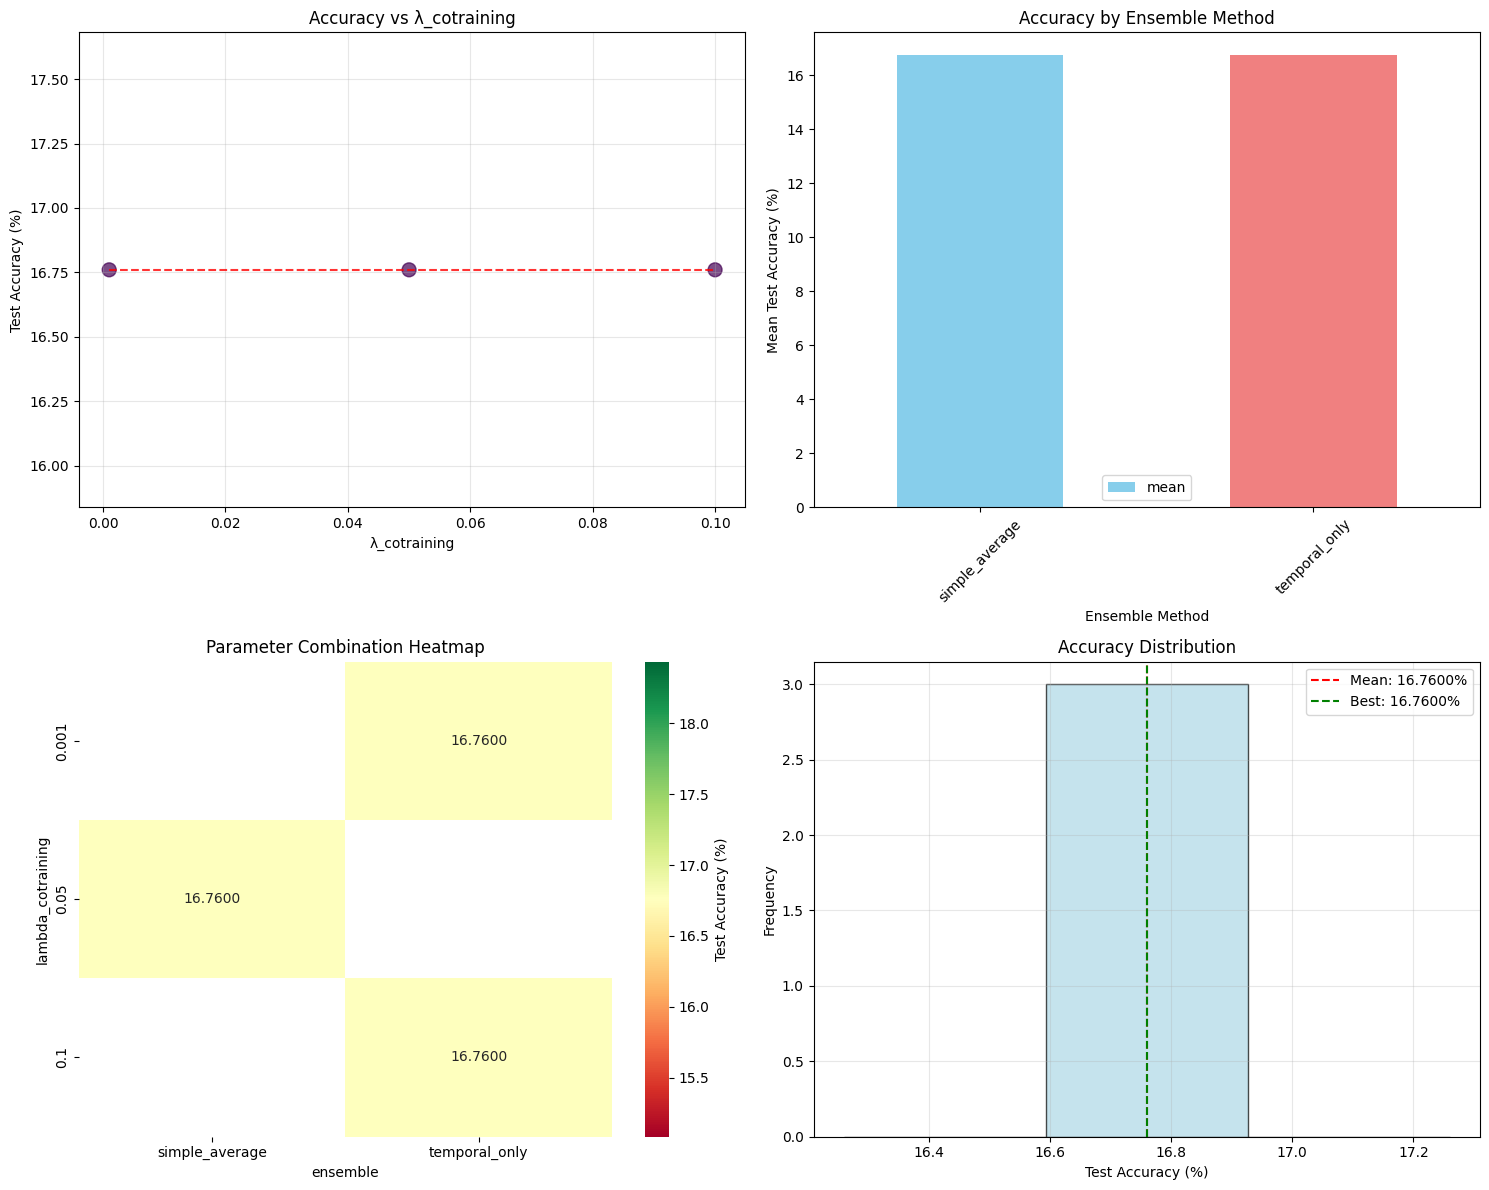


🔍 PARAMETER SENSITIVITY ANALYSIS:
──────────────────────────────────────────────────
λ_cotraining correlation with accuracy: nan

λ_cotraining performance:
  λ_ct=0.001: 16.7600% (±nan)
  λ_ct=0.05: 16.7600% (±nan)
  λ_ct=0.1: 16.7600% (±nan)

Ensemble method performance:
  simple_average: 16.7600% (±nan, n=1.0)
  temporal_only: 16.7600% (±0.0000, n=2.0)

🏆 TOP 3 CONFIGURATIONS:
──────────────────────────────────────────────────
  1. λ_ct=0.001, λ_cs=0.1, temporal_only: 16.7600%
  2. λ_ct=0.05, λ_cs=0.2, simple_average: 16.7600%
  3. λ_ct=0.1, λ_cs=0.1, temporal_only: 16.7600%

📦 Results package created: gridsearch_20250622_095257/coft_gridsearch_results_20250622_095751.zip
📊 Summary saved: gridsearch_20250622_095257/analysis_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Results automatically downloaded!

✨ Analysis complete! Ready for next optimization round.


In [12]:
# ===================================================================
# CELL 5: Advanced Visualization & Analysis
# ===================================================================

def analyze_results(results_file):
    """Comprehensive analysis and visualization of grid search results"""

    try:
        # Load results
        df = pd.read_csv(results_file)
        df = df[df['test_accuracy'] != 'FAILED'].copy()
        df['test_accuracy'] = pd.to_numeric(df['test_accuracy'])

        if len(df) == 0:
            print("⚠️  No successful experiments to analyze")
            return

        print("📈 ADVANCED ANALYSIS & VISUALIZATION")
        print("═" * 70)

        # Basic statistics
        print(f"✅ Successful experiments: {len(df)}")
        print(f"📊 Mean accuracy: {df['test_accuracy'].mean():.4f}%")
        print(f"📊 Std deviation: {df['test_accuracy'].std():.4f}%")
        print(f"🏆 Best accuracy: {df['test_accuracy'].max():.4f}%")
        print(f"📉 Worst accuracy: {df['test_accuracy'].min():.4f}%")

        # Create visualizations
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # 1. Accuracy by Lambda Cotraining
        axes[0,0].scatter(df['lambda_cotraining'], df['test_accuracy'],
                         c=df['test_accuracy'], cmap='viridis', s=100, alpha=0.7)
        axes[0,0].set_xlabel('λ_cotraining')
        axes[0,0].set_ylabel('Test Accuracy (%)')
        axes[0,0].set_title('Accuracy vs λ_cotraining')
        axes[0,0].grid(True, alpha=0.3)

        # Add trend line
        if len(df) > 1:
            z = np.polyfit(df['lambda_cotraining'], df['test_accuracy'], 1)
            p = np.poly1d(z)
            axes[0,0].plot(df['lambda_cotraining'], p(df['lambda_cotraining']), "r--", alpha=0.8)

        # 2. Ensemble Method Comparison
        if 'ensemble' in df.columns:
            ensemble_stats = df.groupby('ensemble')['test_accuracy'].agg(['mean', 'std', 'count'])
            ensemble_stats.plot(kind='bar', y='mean', ax=axes[0,1],
                              color=['skyblue', 'lightcoral'])
            axes[0,1].set_title('Accuracy by Ensemble Method')
            axes[0,1].set_ylabel('Mean Test Accuracy (%)')
            axes[0,1].set_xlabel('Ensemble Method')
            axes[0,1].tick_params(axis='x', rotation=45)

        # 3. Heatmap of Parameter Combinations
        if len(df) > 2:
            pivot_data = df.pivot_table(values='test_accuracy',
                                      index='lambda_cotraining',
                                      columns='ensemble',
                                      aggfunc='mean')
            sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='RdYlGn',
                       ax=axes[1,0], cbar_kws={'label': 'Test Accuracy (%)'})
            axes[1,0].set_title('Parameter Combination Heatmap')

        # 4. Distribution of Results
        axes[1,1].hist(df['test_accuracy'], bins=min(10, len(df)),
                      color='lightblue', alpha=0.7, edgecolor='black')
        axes[1,1].axvline(df['test_accuracy'].mean(), color='red',
                         linestyle='--', label=f'Mean: {df["test_accuracy"].mean():.4f}%')
        axes[1,1].axvline(df['test_accuracy'].max(), color='green',
                         linestyle='--', label=f'Best: {df["test_accuracy"].max():.4f}%')
        axes[1,1].set_xlabel('Test Accuracy (%)')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title('Accuracy Distribution')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Parameter sensitivity analysis
        print("\n🔍 PARAMETER SENSITIVITY ANALYSIS:")
        print("─" * 50)

        # Lambda cotraining analysis
        if len(df['lambda_cotraining'].unique()) > 1:
            lambda_corr = df[['lambda_cotraining', 'test_accuracy']].corr().iloc[0,1]
            print(f"λ_cotraining correlation with accuracy: {lambda_corr:.4f}")

            lambda_stats = df.groupby('lambda_cotraining')['test_accuracy'].agg(['mean', 'std'])
            print("\nλ_cotraining performance:")
            for idx, (lambda_val, stats) in enumerate(lambda_stats.iterrows()):
                print(f"  λ_ct={lambda_val}: {stats['mean']:.4f}% (±{stats['std']:.4f})")

        # Ensemble method analysis
        if 'ensemble' in df.columns and len(df['ensemble'].unique()) > 1:
            print(f"\nEnsemble method performance:")
            ensemble_stats = df.groupby('ensemble')['test_accuracy'].agg(['mean', 'std', 'count'])
            for ensemble, stats in ensemble_stats.iterrows():
                print(f"  {ensemble}: {stats['mean']:.4f}% (±{stats['std']:.4f}, n={stats['count']})")

        # Best configurations
        print(f"\n🏆 TOP 3 CONFIGURATIONS:")
        print("─" * 50)
        top_3 = df.nlargest(3, 'test_accuracy')[['exp_id', 'lambda_cotraining', 'lambda_consistency', 'ensemble', 'test_accuracy']]
        for idx, row in top_3.iterrows():
            print(f"  {int(row['exp_id'])}. λ_ct={row['lambda_cotraining']}, λ_cs={row['lambda_consistency']}, {row['ensemble']}: {row['test_accuracy']:.4f}%")

        # Export results
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        # Save summary statistics
        with open(f"{RESULTS_DIR}/analysis_summary.txt", 'w') as f:
            f.write("CoFT Grid Search Analysis Summary\n")
            f.write("=" * 40 + "\n\n")
            f.write(f"Total successful experiments: {len(df)}\n")
            f.write(f"Mean accuracy: {df['test_accuracy'].mean():.4f}%\n")
            f.write(f"Best accuracy: {df['test_accuracy'].max():.4f}%\n")
            f.write(f"Standard deviation: {df['test_accuracy'].std():.4f}%\n\n")

            f.write("Top 3 configurations:\n")
            for idx, row in top_3.iterrows():
                f.write(f"  λ_ct={row['lambda_cotraining']}, λ_cs={row['lambda_consistency']}, {row['ensemble']}: {row['test_accuracy']:.4f}%\n")

        # Create downloadable ZIP
        import zipfile
        zip_filename = f"{RESULTS_DIR}/coft_gridsearch_results_{timestamp}.zip"
        with zipfile.ZipFile(zip_filename, 'w') as zipf:
            zipf.write(results_file, f"results_{timestamp}.csv")
            zipf.write(f"{RESULTS_DIR}/analysis_summary.txt", "analysis_summary.txt")
            if os.path.exists(f"{RESULTS_DIR}/best_result.txt"):
                zipf.write(f"{RESULTS_DIR}/best_result.txt", "best_result.txt")

        print(f"\n📦 Results package created: {zip_filename}")
        print(f"📊 Summary saved: {RESULTS_DIR}/analysis_summary.txt")

        # Auto-download in Colab
        try:
            from google.colab import files
            files.download(zip_filename)
            print("📥 Results automatically downloaded!")
        except ImportError:
            print("💡 To download results, copy the files from the results directory")

    except Exception as e:
        print(f"❌ Analysis error: {e}")

# Run analysis if results exist
if os.path.exists(f"{RESULTS_DIR}/results.csv"):
    analyze_results(f"{RESULTS_DIR}/results.csv")
else:
    print("⚠️  No results file found. Run the grid search first!")

print("\n✨ Analysis complete! Ready for next optimization round.")
